### Ejercicios de 4.8 - 4.10 y 4.15 - 4.16

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

4.8 - ¿La cantidad de actores influye en los ingresos de las películas? ¿Se han hecho películas con más actores en los últimos años?

Total de películas: 19883
Películas con ingresos: 5398

Correlacion: Cantidad Actores vs Ingresos
Pearson: 0.3572

Ingresos promedio por cantidad de actores:
             Películas  Promedio_M
cat_actores                       
1-5                119        4.64
6-10               303       46.27
11-20             1206       47.03
20+               3761      133.12


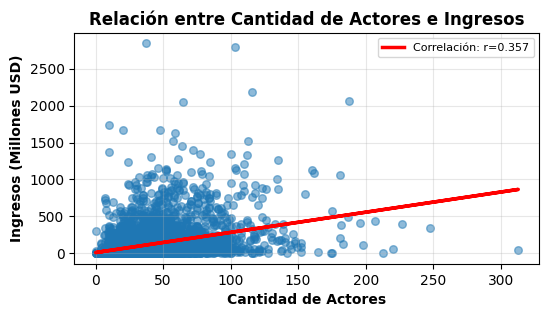

In [33]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin1')

# Filtrar películas con datos financieros (revenue > 0)
df_revenue = df[df['revenue'] > 0].copy()
print(f"Total de películas: {len(df)}")
print(f"Películas con ingresos: {len(df_revenue)}")

# Limpiar los outliers extremos de cantidad de actores para mejor visualizacion
df = df_revenue[df_revenue['actorsAmount'] < 1000].copy()

corr, p_value = stats.pearsonr(df['actorsAmount'], df['revenue'])
print("\nCorrelacion: Cantidad Actores vs Ingresos")
print(f"Pearson: {corr:.4f}")

# Dividir por cantidad de actores
df['cat_actores'] = pd.cut(df['actorsAmount'], bins=[0, 5, 10, 20, 500], labels=['1-5', '6-10', '11-20', '20+'])

print("\nIngresos promedio por cantidad de actores:")
stats_cat = df.groupby('cat_actores')['revenue'].agg([
    ('Películas', 'count'),
    ('Promedio_M', lambda x: x.mean()/1e6),
])
print(stats_cat.round(2))

# Gráfico de dispersión
plt.figure(figsize=(6, 3))
plt.scatter(df['actorsAmount'], df['revenue']/1e6, alpha=0.5, s=30)

# Línea de tendencia
z = np.polyfit(df['actorsAmount'], df['revenue']/1e6, 1)
p = np.poly1d(z)
plt.plot(df['actorsAmount'], p(df['actorsAmount']), 
         "r-", linewidth=2.5, label=f'Correlación: r={corr:.3f}')

plt.xlabel('Cantidad de Actores', fontweight='semibold', fontsize=10)
plt.ylabel('Ingresos (Millones USD)', fontweight='semibold', fontsize=10)
plt.title('Relación entre Cantidad de Actores e Ingresos', fontweight='bold', fontsize=12)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

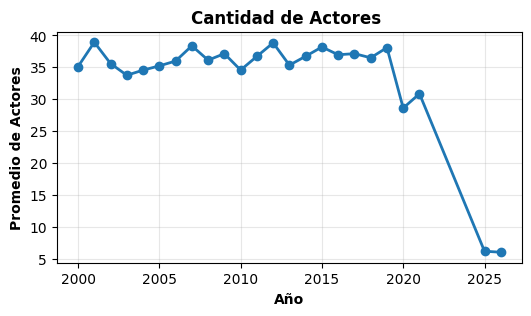

In [6]:
# ¿Más actores en últimos años?
tendencia = df.groupby('releaseYear')['actorsAmount'].mean().reset_index()
tendencia = tendencia[tendencia['releaseYear'] >= 2000]  # Solo años recientes

# Gráfico simple
plt.figure(figsize=(6, 3))
plt.plot(tendencia['releaseYear'], tendencia['actorsAmount'], marker='o', linewidth=2)
plt.xlabel('Año', fontweight='semibold')
plt.ylabel('Promedio de Actores', fontweight='semibold')
plt.title('Cantidad de Actores ', fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

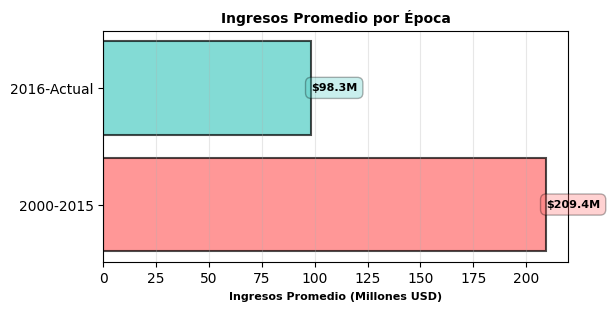

In [37]:
df_revenue = df[df['revenue'] > 0].copy()

#Filtrar por epocas y para que sea una comparacion justa se agarra la misma cantidad de peliculas con los mejores revenues
df_2000_2015 = df_revenue[(df_revenue['releaseYear'] >= 2000) & (df_revenue['releaseYear'] <= 2015)].nlargest(1451, 'revenue')
df_2016_actual = df_revenue[(df_revenue['releaseYear'] >= 2016)].nlargest(1451, 'revenue')


epochs = ['2000-2015', '2016-Actual']
data_2000 = df_2000_2015['revenue'].mean()/1e6
data_2016 = df_2016_actual['revenue'].mean()/1e6

fig, ax = plt.subplots(figsize=(6, 3))

ingresos = [data_2000, data_2016]
colors = ['#FF6B6B', '#4ECDC4']

bars = ax.barh(epochs, ingresos, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Ingresos Promedio (Millones USD)', fontweight='bold', fontsize=8)
ax.set_title('Ingresos Promedio por Época', fontweight='bold', fontsize=10)
ax.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, ingresos)):
    ax.text(val, bar.get_y() + bar.get_height()/2.,
           f'${val:.1f}M', ha='left', va='center', fontweight='bold', fontsize=8,
           bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[i], alpha=0.3))

plt.show()

4.9 - ¿Es posible que la cantidad de hombres y mujeres en el reparto influya en la popularidad y los ingresos de las películas? 

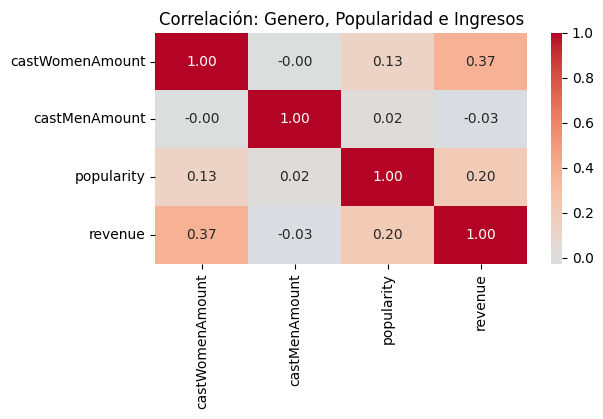

In [13]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin1')
cols = ['castWomenAmount', 'castMenAmount', 'popularity', 'revenue']
df_clean = df[cols].dropna()

# 2. Cálculo de la matriz de correlación (Pearson)
corr_matrix = df_clean.corr()

# 3. Creación del Mapa de Calor
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)

plt.title('Correlación: Genero, Popularidad e Ingresos')
plt.show()

4.10 - ¿Quiénes son los directores que hicieron las 20 películas mejor 
calificadas?

In [44]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin-1')

top_20_directores = (
    df.groupby('director')['voteAvg']
      .mean()
      .sort_values(ascending=False)
      .head(20)
      .reset_index()
)

print("TOP DIRECTORES")

for idx, director in enumerate(top_20_directores['director'], 1):
    movies = df[df['director'] == director][['title', 'voteAvg', 'releaseYear', 'revenue', 'budget']].sort_values('releaseYear')
    is_emergent = 'Sí' if movies['releaseYear'].min() >= 2020 else 'No (antes 2020)'
    
    print(f"\n{idx}. {director}")
    print(f"¿Emergente?: {is_emergent}")

TOP DIRECTORES

1. Jackson Driver
¿Emergente?: Sí

2. Aarish Ahmed|Zayne Wint
¿Emergente?: Sí

3. ADRIAN PERERA
¿Emergente?: Sí

4. Scout Georgas
¿Emergente?: Sí

5. Scott Leeker
¿Emergente?: Sí

6. Selena MarÃ­a Ortiz
¿Emergente?: Sí

7. Scarlett J. Stribley
¿Emergente?: Sí

8. Savannah Tuesday
¿Emergente?: Sí

9. James Osborn|Audrey Robinson
¿Emergente?: Sí

10. nawaf almutairi
¿Emergente?: Sí

11. Felix Baughan
¿Emergente?: Sí

12. Umay Melek Aymutlu
¿Emergente?: Sí

13. Filip Stojiljkovic
¿Emergente?: Sí

14. Ved
¿Emergente?: Sí

15. Fernando Teixeira Florencio
¿Emergente?: Sí

16. Ferliana Putri Arya Anindita
¿Emergente?: Sí

17. Fernanda Neu
¿Emergente?: Sí

18. Kurtis Spralja|Thomas Livingstone|Kai Dutch
¿Emergente?: Sí

19. Kyan McDonald
¿Emergente?: Sí

20. Kyle Christian
¿Emergente?: Sí


4.15 - ¿Qué estrategias de marketing, como videos promocionales o páginas 
oficiales, generan mejores resultados? 

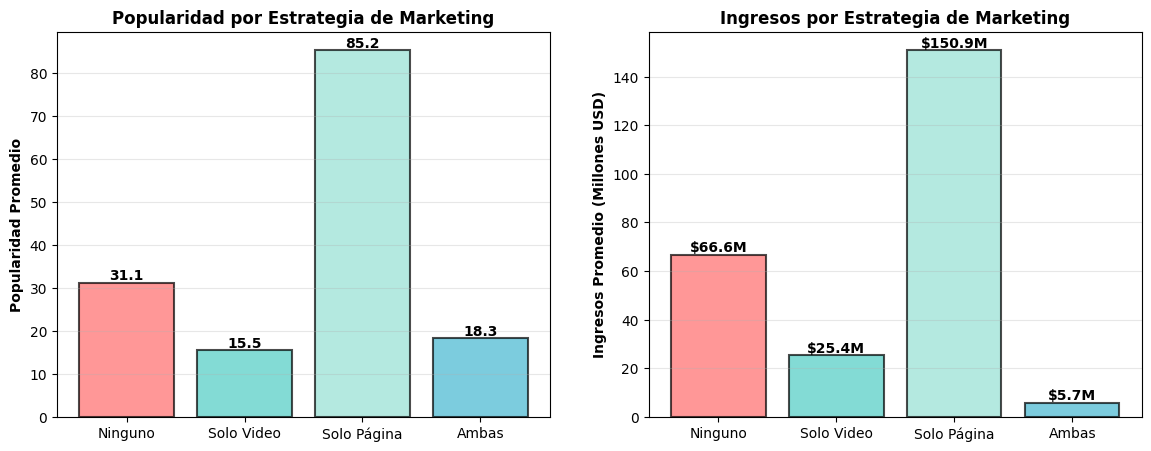

In [24]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin-1')

df_analisis = df[(df['revenue'] > 0) & (df['popularity'] > 0)].copy()

df_analisis['has_video'] = df_analisis['video'].fillna(False).astype(bool)
df_analisis['has_homepage'] = df_analisis['homePage'].notna() & (df_analisis['homePage'] != '')

df_analisis['marketing_cat'] = 'Ninguno'
df_analisis.loc[df_analisis['has_video'] & ~df_analisis['has_homepage'], 'marketing_cat'] = 'Solo Video'
df_analisis.loc[~df_analisis['has_video'] & df_analisis['has_homepage'], 'marketing_cat'] = 'Solo Página'
df_analisis.loc[df_analisis['has_video'] & df_analisis['has_homepage'], 'marketing_cat'] = 'Ambas'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Ninguno', 'Solo Video', 'Solo Página', 'Ambas']
pop_data = [df_analisis[df_analisis['marketing_cat'] == cat]['popularity'].mean() for cat in categories]
rev_data = [(df_analisis[df_analisis['marketing_cat'] == cat]['revenue'].mean() / 1e6) for cat in categories]

colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#45B7D1']

bars1 = axes[0].bar(categories, pop_data, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Popularidad Promedio', fontweight='bold')
axes[0].set_title('Popularidad por Estrategia de Marketing', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, pop_data):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

bars2 = axes[1].bar(categories, rev_data, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Ingresos Promedio (Millones USD)', fontweight='bold')
axes[1].set_title('Ingresos por Estrategia de Marketing', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, rev_data):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'${val:.1f}M', ha='center', va='bottom', fontweight='bold')


plt.show()

4.16 - ¿La popularidad del elenco está directamente correlacionada con el éxito de taquilla?


Correlación de Pearson: 1.0000
p-value: 1.337e-05


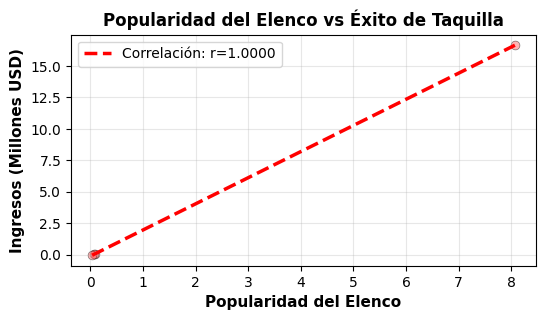

In [ ]:
df = pd.read_csv('../data/movies_2026.csv', encoding='latin-1')

df['actorsPopularity'] = pd.to_numeric(df['actorsPopularity'], errors='coerce')

df_analisis = df[(df['revenue'] > 0) & (df['actorsPopularity'].notna()) & (df['actorsPopularity'] != 0)].copy()

if len(df_analisis) > 2:
    corr, p_value = stats.pearsonr(df_analisis['actorsPopularity'], df_analisis['revenue'])
else:
    corr, p_value = np.nan, np.nan

print(f"\nCorrelación de Pearson: {corr:.4f}")
print(f"p-value: {p_value:.3e}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(df_analisis['actorsPopularity'], df_analisis['revenue']/1e6, alpha=0.5, s=40, color='#FF6B6B', edgecolor='black', linewidth=0.5)
z = np.polyfit(df_analisis['actorsPopularity'], df_analisis['revenue']/1e6, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(df_analisis['actorsPopularity'].min(), df_analisis['actorsPopularity'].max(), 100)
ax.plot(x_line, p_fit(x_line), "r--", linewidth=2.5, label=f'Correlación: r={corr:.4f}')

ax.set_xlabel('Popularidad del Elenco', fontweight='bold', fontsize=11)
ax.set_ylabel('Ingresos (Millones USD)', fontweight='bold', fontsize=11)
ax.set_title('Popularidad del Elenco vs Éxito de Taquilla', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.show()